# EDA — FIFA World Cup 2026 Player Performance Dataset

Notebook khám phá dữ liệu trước khi đưa vào pipeline chính (`main.py`). Chạy các ô bên dưới theo thứ tự để hiểu cấu trúc dữ liệu, phân phối chỉ số, và kiểm tra chất lượng dữ liệu trước khi model hoá.

In [1]:
import sys
import os
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import load_config, resolve_path

cfg = load_config('../config.yaml')
path = resolve_path(cfg['data']['raw_player_file'])
df = pd.read_csv(path)
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


## 1. Tổng quan dữ liệu

In [23]:
print(df.shape)
df.info()
df.describe()

(54600, 75)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


## 2. Kiểm tra dữ liệu thiếu / trùng lặp

In [24]:
print('Missing values:')
print(df.isnull().sum())
print()
print('Số dòng trùng lặp:', df.duplicated().sum())

Missing values:
player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64

Số dòng trùng lặp: 0


## 3. Phân phối player_rating theo vị trí

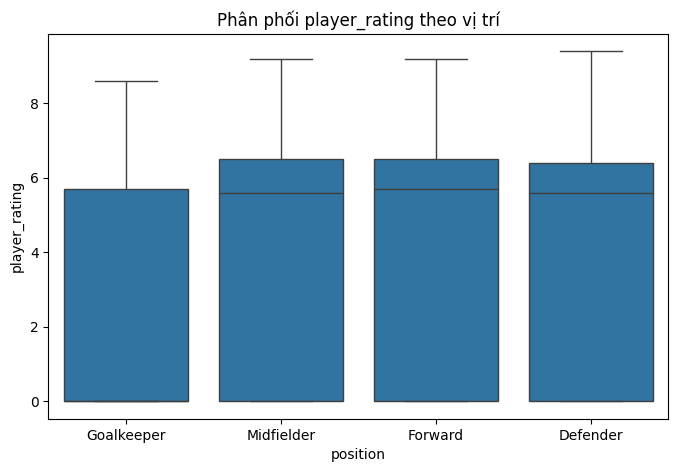

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='position', y='player_rating')
plt.title('Phân phối player_rating theo vị trí')
plt.show()

## 4. Top 10 đội có squad_avg_rating cao nhất (đội hình chính top-15 theo phút thi đấu)

In [2]:
from src.data_processing import PlayerDataProcessor
processor = PlayerDataProcessor(cfg)
team_stats = processor.run(save=False)
team_stats.sort_values('squad_avg_rating', ascending=False).head(10)

[09:20:18] INFO - src.data_processing - Đã đọc 54600 dòng cầu thủ từ F:\world_cup_predictor\data\raw\fifa_world_cup_2026_player_performance.csv
[09:20:18] INFO - src.data_processing - Phát hiện cột tổng-cả-giải có sẵn -> dùng trực tiếp thay vì tự cộng dồn
[09:20:18] INFO - src.data_processing - Đã gộp 54600 dòng cấp trận đấu -> 1248 dòng cấp cầu thủ
[09:20:18] INFO - src.data_processing - Đã lọc còn 720 cầu thủ (top 15 theo phút thi đấu / đội)
[09:20:18] INFO - src.data_processing - Đã gộp dữ liệu cho 48 đội tuyển


,national_team,squad_avg_rating,squad_max_rating,squad_avg_clutch,total_goals,total_assists,total_xg,squad_size
25,Morocco,7.940000,8.9,56.502788,48,45,15.51,15
20,Iraq,7.913333,9.2,57.294146,58,41,17.42,15
0,Algeria,7.906667,9.1,55.819187,45,43,11.39,15
32,Qatar,7.880000,8.8,56.061919,50,41,20.67,15
6,Cameroon,7.860000,8.9,55.499242,51,41,17.77,15
23,Japan,7.853333,8.5,56.912222,49,48,9.77,15
15,England,7.833333,8.5,55.730606,39,41,11.26,15
21,Italy,7.780000,8.8,55.190063,36,42,11.49,15
14,Egypt,7.753333,9.3,55.799852,50,43,9.43,15
31,Portugal,7.746667,8.9,55.784651,49,43,10.38,15


## 5. Tương quan giữa các chỉ số cầu thủ

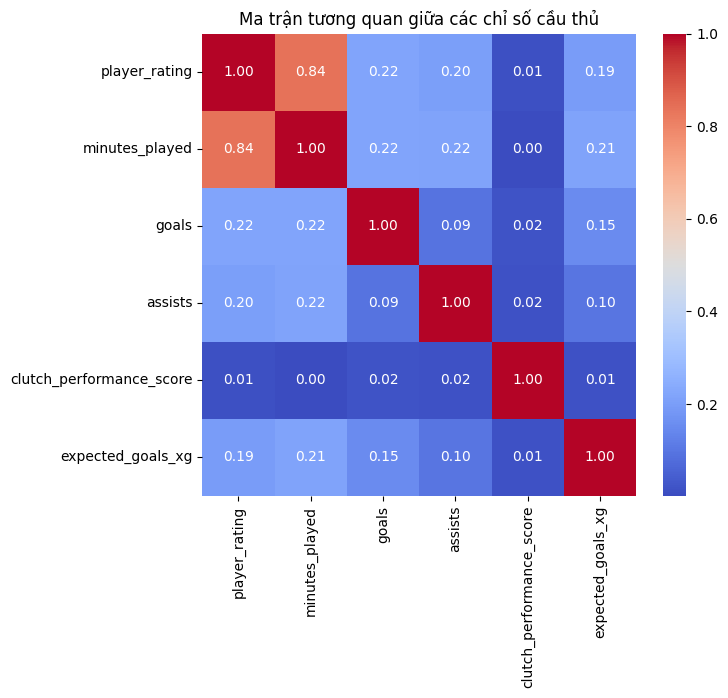

In [28]:
numeric_cols = ['player_rating', 'minutes_played', 'goals', 'assists',
                'clutch_performance_score', 'expected_goals_xg']
corr = df[numeric_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các chỉ số cầu thủ')
plt.show()

## 6. Power Index sau khi tính toán (feature_engineering.py)

[09:20:18] INFO - src.feature_engineering - Top 5 đội theo Power Index:
national_team  power_index  power_attack_norm  power_midfield_norm  power_defense_norm
      Algeria         50.0               50.0                 50.0                50.0
    Argentina         50.0               50.0                 50.0                50.0
    Australia         50.0               50.0                 50.0                50.0
      Austria         50.0               50.0                 50.0                50.0
      Belgium         50.0               50.0                 50.0                50.0


F:\temp\ipykernel_16180\2574826550.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x='power_index', y='national_team', palette='viridis')


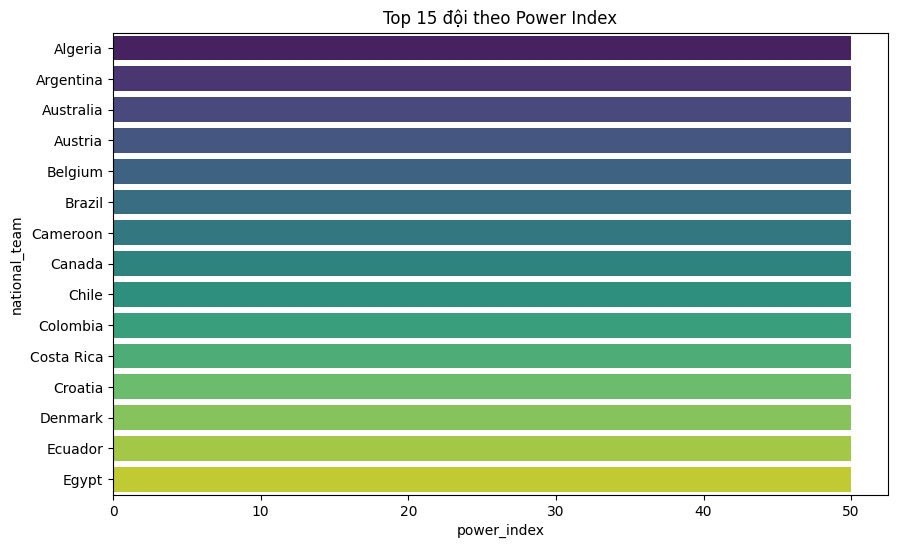

In [3]:
from src.feature_engineering import FeatureEngineer
fe = FeatureEngineer(cfg)
result = fe.run(team_stats)
plt.figure(figsize=(10,6))
top15 = result.head(15)
sns.barplot(data=top15, x='power_index', y='national_team', palette='viridis')
plt.title('Top 15 đội theo Power Index')
plt.show()